In [24]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Display all columns
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/raw/heart.csv")
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


Basic Information

In [25]:
print("Shape:", df.shape)
df.info()

Shape: (303, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


Statistical Summary

In [26]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


Check Missing Values

In [27]:

df.replace("?", np.nan, inplace=True)
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Missing Value Heatmap

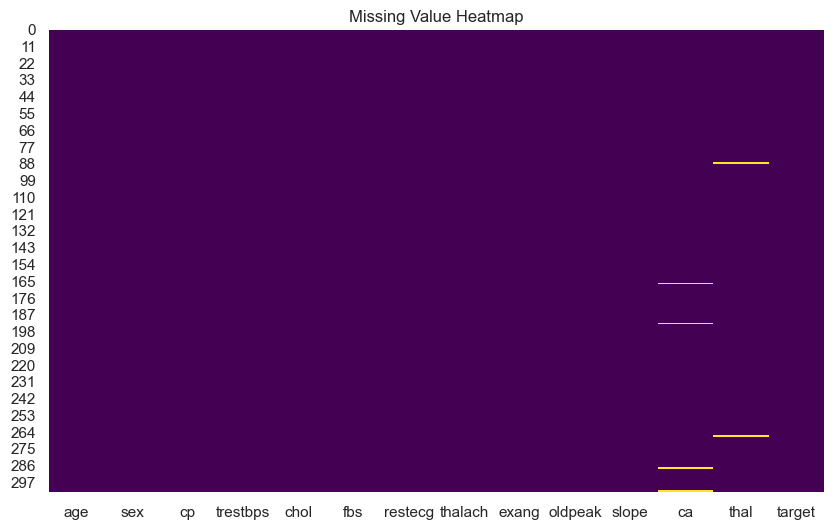

<Figure size 640x480 with 0 Axes>

In [28]:
plt.figure(figsize=(10,6))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Missing Value Heatmap")

plt.show()

plt.savefig("../screenshots/missing_values.png")

Check Data Types

In [29]:
df.dtypes

df["ca"] = pd.to_numeric(df["ca"], errors="coerce")
df["thal"] = pd.to_numeric(df["thal"], errors="coerce")

df.dtypes



age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Check Duplicate Rows

In [30]:
print("Duplicate Rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print(df.shape)

Duplicate Rows: 0
(303, 14)


Class Distribution

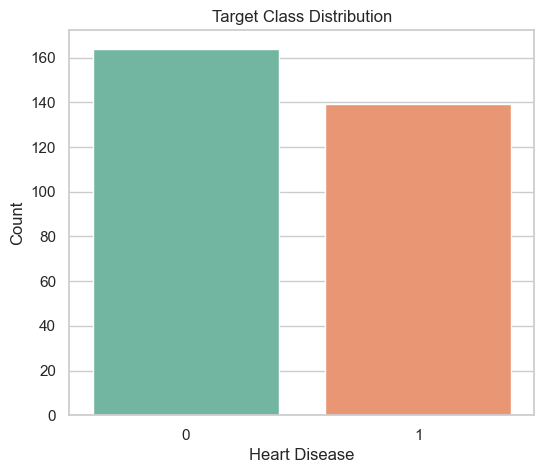

In [31]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="target",
    data=df,
    palette="Set2"
)

plt.title("Target Class Distribution")

plt.xlabel("Heart Disease")

plt.ylabel("Count")

plt.show()

The dataset is relatively balanced between patients with and without heart disease, making it suitable for binary classification

Histograms

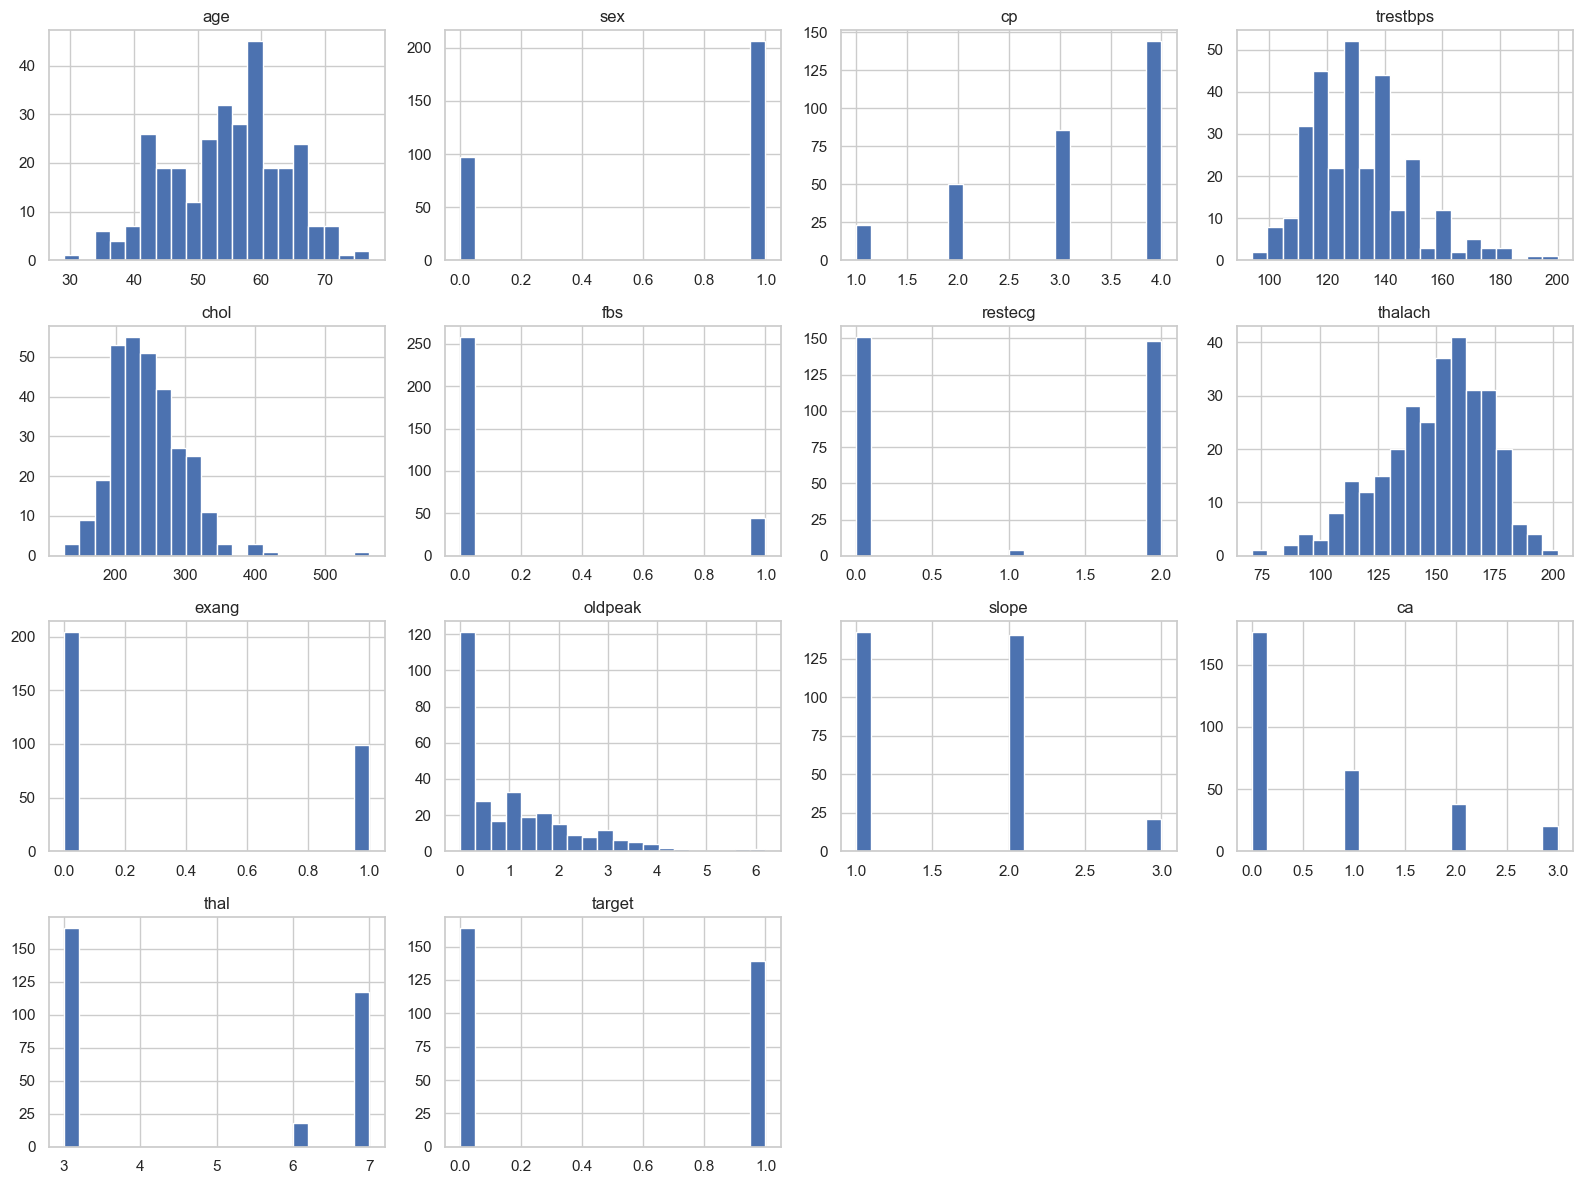

In [32]:
df.hist(
    figsize=(16,12),
    bins=20
)

plt.tight_layout()

plt.show()

Correlation Heatmap

The strongest correlations with the target are observed for chest pain (cp), maximum heart rate (thalach), and exercise-induced angina (exang). Cholesterol shows a weaker linear correlation.

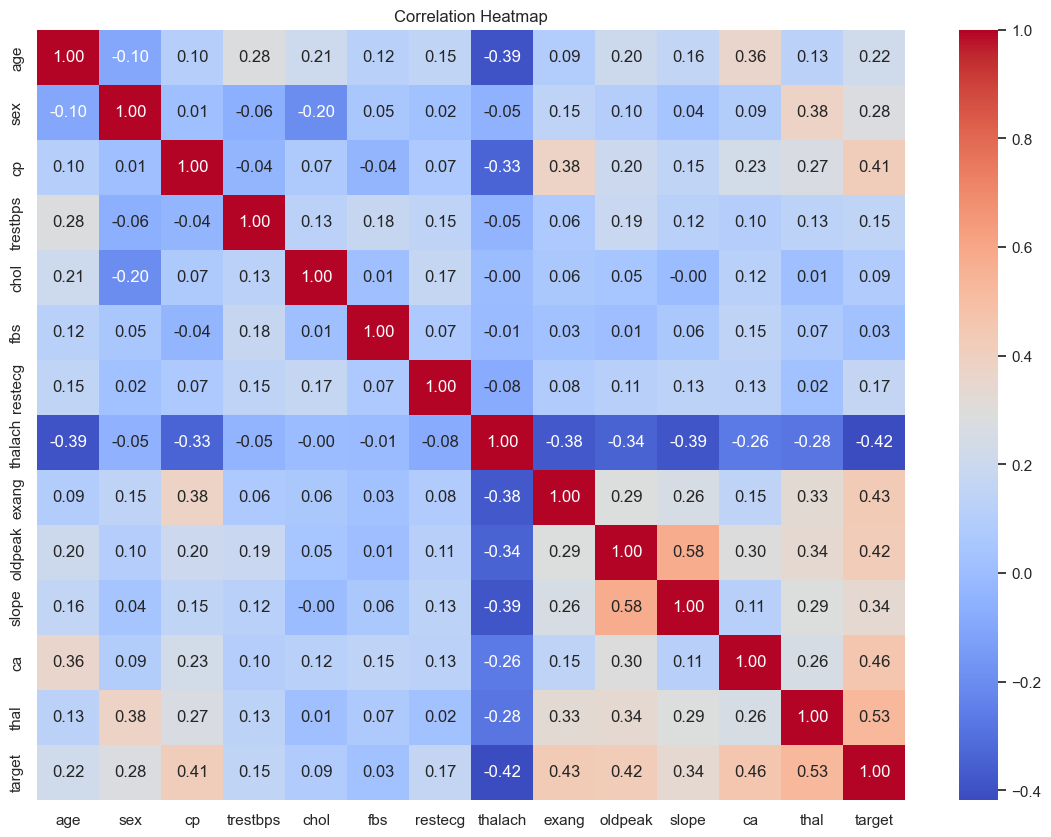

In [33]:
plt.figure(figsize=(14,10))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

Feature Relationship Analysis

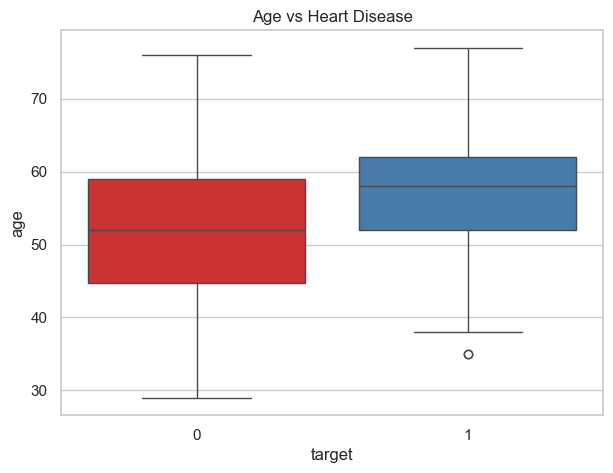

In [34]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="target",
    y="age",
    data=df,
    palette="Set1"
)

plt.title("Age vs Heart Disease")

plt.show()

Cholesterol vs Target

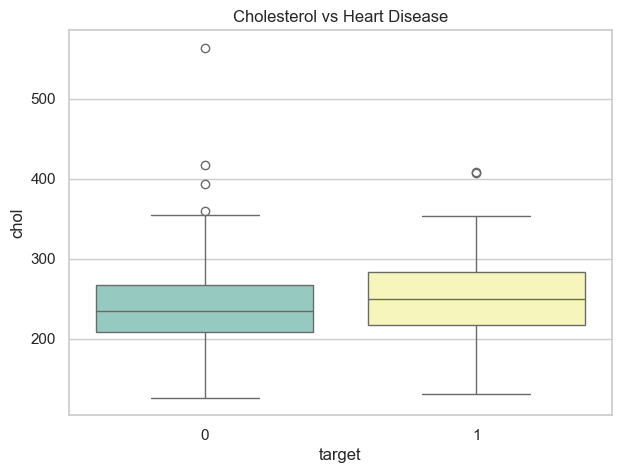

In [35]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="target",
    y="chol",
    data=df,
    palette="Set3"
)

plt.title("Cholesterol vs Heart Disease")

plt.show()

Resting Blood Pressure vs Target

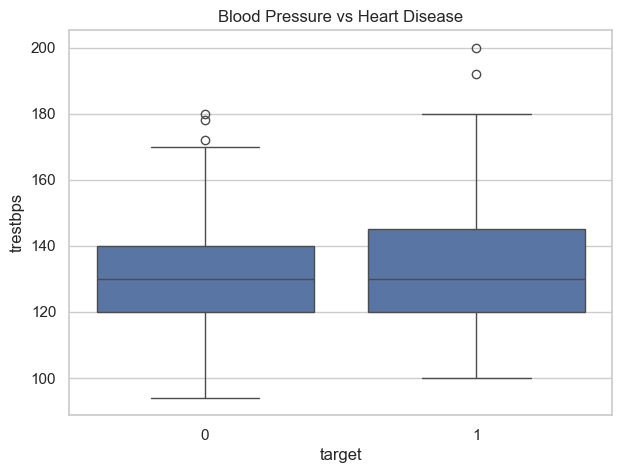

In [36]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="target",
    y="trestbps",
    data=df
)

plt.title("Blood Pressure vs Heart Disease")

plt.show()

Maximum Heart Rate vs Target

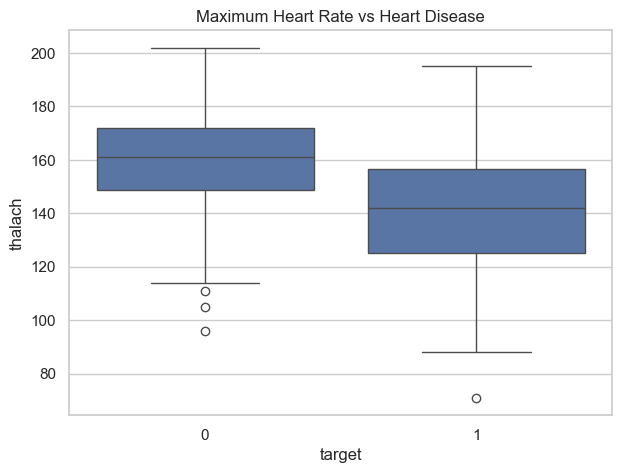

In [37]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="target",
    y="thalach",
    data=df
)

plt.title("Maximum Heart Rate vs Heart Disease")

plt.show()

Pairplot

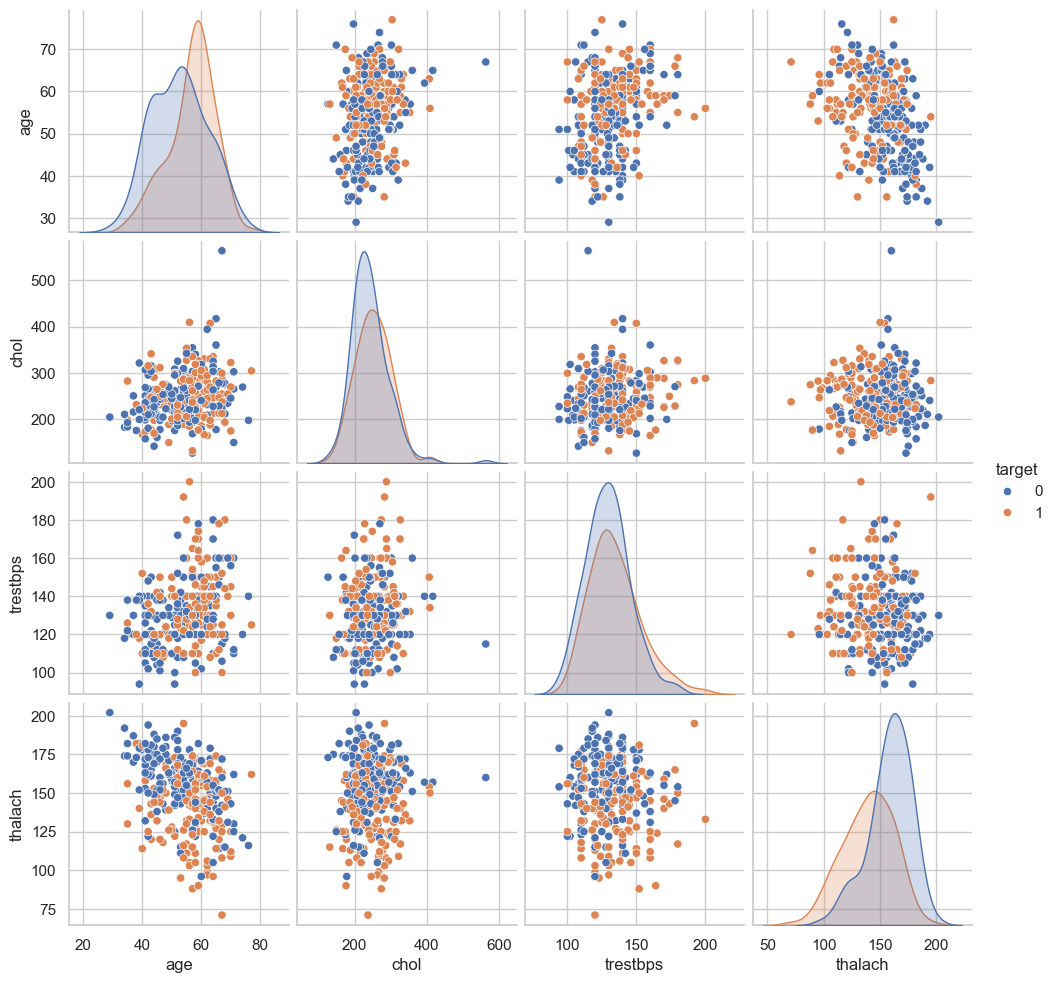

In [38]:
sns.pairplot(
    df[
        [
            "age",
            "chol",
            "trestbps",
            "thalach",
            "target"
        ]
    ],
    hue="target"
)

plt.show()

Save Clean Dataset

In [39]:
df.to_csv("../data/processed/heart_clean.csv", index=False)

print("Clean dataset saved.")

Clean dataset saved.
